In [1]:
# Data Profiling - Jobs in Data (dirty layer)
# Profile bản dirty (data/raw_dirty/) thay vì raw, để thấy đầy đủ các vấn đề
# mà bước cleaning sẽ phải xử lý: NULL, duplicates, sai dtype, typo, outlier...

import os
import sys
from pathlib import Path

# ensure project root is on sys.path so `src` is importable from notebook
project_root = Path.cwd().parent
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))
os.chdir(project_root)

# Clear cached modules to ensure fresh import
for mod in list(sys.modules.keys()):
    if mod.startswith('src'):
        del sys.modules[mod]

import yaml
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from src.data.load_data import load_raw_data_with_fallback
from src.data.dirtify import make_dirty_dataset

In [2]:
# Load configuration
with open("config.yaml", "r") as f:
    config = yaml.safe_load(f)

print(f"Project: {config['project']['name']}")
print(f"Dataset: {config['data']['dataset']}")

Project: Jobs in Data Analysis
Dataset: hummaamqaasim/jobs-in-data


In [3]:
# 1. Đảm bảo raw có sẵn (download từ Kaggle nếu chưa có)
raw_path = Path(config["paths"]["raw_data"]) / config["data"]["raw_filename"]
if not raw_path.exists():
    load_raw_data_with_fallback(
        raw_dir=config["paths"]["raw_data"],
        dataset=config["data"]["dataset"],
        filename=config["data"]["raw_filename"],
    )

# 2. Sinh dirty dataset từ raw (idempotent — chỉ tạo nếu chưa tồn tại)
dirty_path = Path(config["paths"]["dirty_data"]) / config["data"]["dirty_filename"]
if not dirty_path.exists():
    make_dirty_dataset(raw_path=raw_path, dirty_path=dirty_path, seed=config["data"]["dirty_seed"])
else:
    print(f"Dirty dataset already exists: {dirty_path}")

# 3. Profile dirty data
df = pd.read_csv(dirty_path)
print(f"Loaded dirty data: {df.shape[0]} rows x {df.shape[1]} cols")
df.head()

Dirty dataset already exists: data\raw_dirty\jobs_in_data_dirty.csv
Loaded dirty data: 9495 rows x 12 cols


,work_year,job_title,job_category,salary_currency,salary,Salary In USD,employee_residence,experience_level,employment_type,work_setting,company_location,CompanySize
0,2023,Data DevOps Engineer,Data Engineering,EUR,88000,95012,Germany,Mid level,Full-time,Hybrid,Germany,L
1,2023,Data Architect,Data Architecture and Modeling,USD,186000,186000,United States,Senior,Full-time,In-person,United States,M
2,2023,Data Architect,Data Architecture and Modeling,USD,81800,81800,United States,senior,Full-time,In-person,United States,M
3,2023,Data Scientist,Data Science and Research,USD,"212,000",212000,United States,Senior,Full-time,In-person,United States,M
4,2023,Data Scientist,Data Science and Research,USD,93300,93300,United States,Senior,Full-time,In-person,United States,M


## 1. Basic Information

In [4]:
# Dataset shape
print(f"Rows: {df.shape[0]:,}")
print(f"Columns: {df.shape[1]}")
print(f"\nColumn names:\n{df.columns.tolist()}")

Rows: 9,495
Columns: 12

Column names:
['work_year', 'job_title', 'job_category', 'salary_currency', 'salary', 'Salary In USD', 'employee_residence', 'experience_level', 'employment_type', 'work_setting', 'company_location', 'CompanySize']


In [5]:
# Data types and memory usage
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9495 entries, 0 to 9494
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   work_year           9495 non-null   int64 
 1   job_title           9495 non-null   object
 2   job_category        9130 non-null   object
 3   salary_currency     9119 non-null   object
 4   salary              9495 non-null   object
 5   Salary In USD       9495 non-null   int64 
 6   employee_residence  9495 non-null   object
 7   experience_level    9117 non-null   object
 8   employment_type     9495 non-null   object
 9   work_setting        9094 non-null   object
 10  company_location    9495 non-null   object
 11  CompanySize         9104 non-null   object
dtypes: int64(2), object(10)
memory usage: 890.3+ KB


#### Schema of data sources:
![data source schema](..\outputs\data_schema\raw_data_schema.png)

## 2. Statistical Summary

In [6]:
# Numerical columns statistics
df.describe()

,work_year,Salary In USD
count,9495.000000,9.495000e+03
mean,2022.760190,1.782486e+05
std,0.519572,7.190146e+05
min,2020.000000,1.500000e+04
25%,2023.000000,1.057000e+05
50%,2023.000000,1.432000e+05
75%,2023.000000,1.870000e+05
max,2023.000000,3.316400e+07


In [7]:
# Categorical columns statistics
df.describe(include='object')

,job_title,job_category,salary_currency,salary,employee_residence,experience_level,employment_type,work_setting,company_location,CompanySize
count,9495,9130,9119,9495,9495,9117,9495,9094,9495,9104
unique,230,43,11,1670,83,23,10,16,70,6
top,Data Engineer,Data Science and Research,USD,150000,United States,Senior,Full-time,In-person,United States,M
freq,2122,2788,8366,211,8203,6020,8699,5095,8250,7970


In [8]:
# Print all unique value of job titile, employee_residence, company_location
print(f"Unique job titles: {df['job_title'].nunique()}")
# Display all distinct job titles
print(df["job_title"].unique())

print(f"Unique employee residences: {df['employee_residence'].nunique()}")
print(df["employee_residence"].unique())

print(f"Unique company locations: {df['company_location'].nunique()}")
print(df["company_location"].unique())


Unique job titles: 230
['Data DevOps Engineer' 'Data Architect' 'Data Scientist'
 'Machine Learning Researcher' 'Data Engineer' 'Machine Learning Engineer'
 'Data Analyst' 'Analytics Engineer' 'machine learning engineer'
 'Applied Scientist' 'APPLIED SCIENTIST' 'MACHINE LEARNING ENGINEER'
 'BI Developer' 'Business Intelligence Engineer'
 'Machine Learning Engineer ' 'Research Scientist' 'Research Analyst'
 ' Data Engineer' 'Research Engineer' 'Data Science Engineer'
 'Data Engineer ' 'Data Quality Analyst' 'Data Product Manager'
 'Data Analyst ' 'Machine Learning Scientist' 'AI Engineer'
 'MLOps Engineer' 'Data Scientist ' 'Deep Learning Engineer'
 'Data Modeler' 'Data Product Owner' ' Data Scientist'
 'Data Science Consultant' 'data science consultant' 'DATA ENGINEER'
 'data scientist' 'business intelligence analyst'
 'Business Intelligence Analyst' 'AI Developer' 'Data Architect '
 'BUSINESS INTELLIGENCE ANALYST' 'AI Engineer ' 'Data Manager'
 'ML Engineer' 'Data Science Director' 'H

## 3. Missing Values Analysis

In [9]:
# Missing values count and percentage
missing = pd.DataFrame({
    'missing_count': df.isnull().sum(),
    'missing_pct': (df.isnull().sum() / len(df) * 100).round(2)
})
missing = missing[missing['missing_count'] > 0].sort_values('missing_count', ascending=False)

if len(missing) > 0:
    print("Columns with missing values:")
    display(missing)
else:
    print("No missing values found!")

Columns with missing values:


,missing_count,missing_pct
work_setting,401,4.22
CompanySize,391,4.12
experience_level,378,3.98
salary_currency,376,3.96
job_category,365,3.84


## 4. Unique Values Analysis

In [10]:
# Unique values per column
unique_counts = pd.DataFrame({
    'unique_count': df.nunique(),
    'dtype': df.dtypes
}).sort_values('unique_count')
unique_counts

,unique_count,dtype
work_year,4,int64
CompanySize,6,object
employment_type,10,object
salary_currency,11,object
work_setting,16,object
experience_level,23,object
job_category,43,object
company_location,70,object
employee_residence,83,object
job_title,230,object


In [11]:
# Value counts for categorical columns (low cardinality)
categorical_cols = df.select_dtypes(include='object').columns
for col in categorical_cols:
    if df[col].nunique() <= 15:
        print(f"\n{col}:")
        print(df[col].value_counts())


salary_currency:
salary_currency
USD    8366
GBP     342
EUR     333
CAD      37
AUD      12
PLN       8
SGD       6
BRL       5
CHF       4
TRY       3
DKK       3
Name: count, dtype: int64

employment_type:
employment_type
Full-time     8699
Fulltime       265
FULL-TIME      138
 Full-time     125
full-time      111
Full-time      110
Contract        17
Part-time       15
Freelance       13
Contrct          2
Name: count, dtype: int64

CompanySize:
CompanySize
M     7970
L      709
 M     249
S      150
l       22
s        4
Name: count, dtype: int64


## 5. Duplicate Rows Check

In [12]:
# Check for duplicate rows
duplicates = df.duplicated().sum()
print(f"Duplicate rows: {duplicates} ({duplicates/len(df)*100:.2f}%)")

Duplicate rows: 1923 (20.25%)


## 6. Data Profiling Summary

**Key observations to document:**
- Total records and features
- Data types distribution
- Missing values pattern
- High/low cardinality columns
- Potential target variable for analysis

In [13]:
# Summary statistics
print("=" * 50)
print("DATA PROFILING SUMMARY")
print("=" * 50)
print(f"Total rows: {len(df):,}")
print(f"Total columns: {len(df.columns)}")
print(f"Numerical columns: {len(df.select_dtypes(include='number').columns)}")
print(f"Categorical columns: {len(df.select_dtypes(include='object').columns)}")
print(f"Missing values: {df.isnull().sum().sum()}")
print(f"Duplicate rows: {df.duplicated().sum()}")
print(f"Memory usage: {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")
print("=" * 50)

DATA PROFILING SUMMARY
Total rows: 9,495
Total columns: 12
Numerical columns: 2
Categorical columns: 10
Missing values: 1911
Duplicate rows: 1923
Memory usage: 5.40 MB


## 7. Data explorations


Draw some diagram to explore data distribution and find out dataset issues


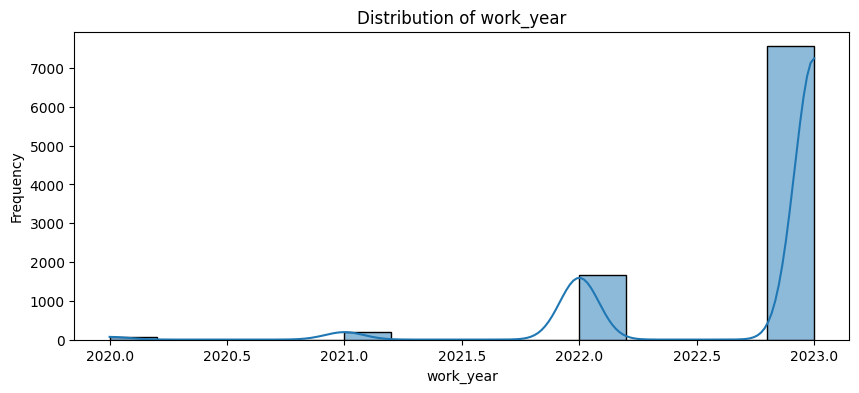

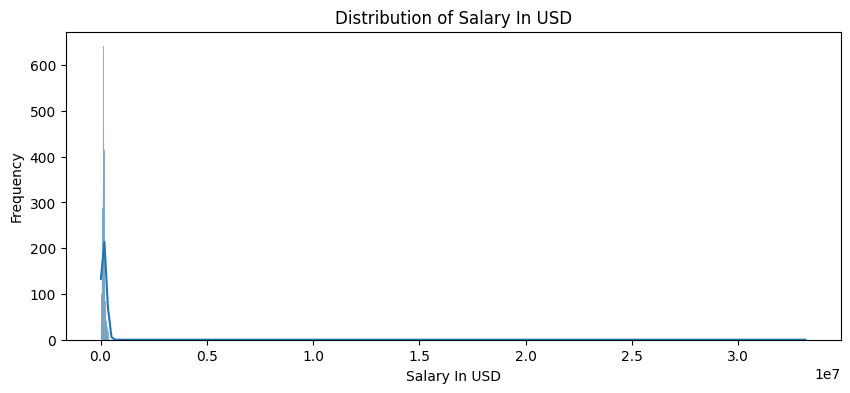

In [14]:
# Draw caster for numerical columns
numerical_cols = df.select_dtypes(include='number').columns
for col in numerical_cols:
    plt.figure(figsize=(10, 4))
    sns.histplot(df[col].dropna(), kde=True)
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.show()

- Vẽ pair plot cho các trường numeric

Giải thích các thành phần trong pair plot:

- Diagonal: Biểu đồ histogram cho từng cột số, giúp ta thấy phân phối dữ liệu.
- Off-diagonal: Biểu đồ scatter giữa các cặp cột số, giúp ta thấy mối quan hệ giữa chúng (nếu có). Nếu có xu hướng tuyến tính, cụm, hoặc mối quan hệ phi tuyến, sẽ hiển thị rõ ràng ở đây.

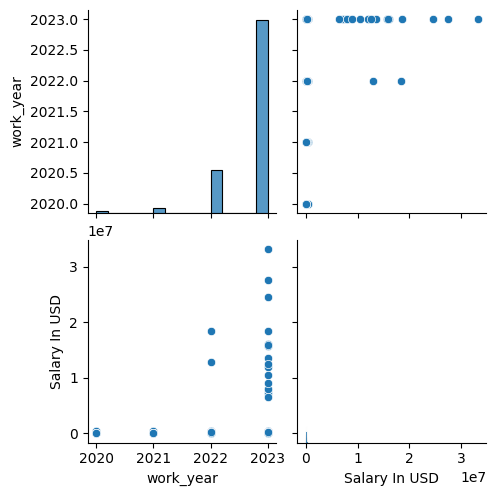

In [15]:
# scatter plot for numerical columns in seperate frame
sns.pairplot(df.select_dtypes(include='number').dropna())
